# Mean–variance allocation: what is a return forecast worth?

An efficient frontier is a statement about assumed returns and covariance. This constructed three-asset example separates the optimization problem from the reliability of its inputs; it contains no historical backtest.

In [1]:
from pathlib import Path
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import PercentFormatter
from scipy.optimize import minimize
from IPython.display import display
ROOT = next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / 'research/allocation.py').is_file())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
plt.rcParams.update({'figure.figsize': (9, 4.8), 'font.size': 11, 'axes.spines.top': False,
                     'axes.spines.right': False, 'axes.grid': True, 'grid.alpha': 0.18})

## Assumptions

All returns and covariance below are annual quantities. Weights are nonnegative and sum to one. The asset labels describe illustrative exposures rather than ETF estimates.

In [2]:
names = ['Growth asset', 'Intermediate bonds', 'Short bonds']
mu = np.array([0.08, 0.045, 0.03])
vol = np.array([0.18, 0.08, 0.025])
corr = np.array([[1, 0.20, 0.10], [0.20, 1, 0.35], [0.10, 0.35, 1]])
cov = np.outer(vol, vol) * corr
assert np.linalg.eigvalsh(cov).min() > 0
display(pd.DataFrame({'Expected annual return': mu, 'Annual volatility': vol}, index=names).style.format('{:.1%}'))

def solve(objective, extra=()):
    fit = minimize(objective, np.full(3, 1/3), method='SLSQP', bounds=[(0, 1)]*3,
                   constraints=[{'type': 'eq', 'fun': lambda w: w.sum()-1}, *extra],
                   options={'ftol': 1e-12, 'maxiter': 1000})
    assert fit.success, fit.message
    assert abs(fit.x.sum()-1) < 1e-8 and fit.x.min() > -1e-8
    return fit.x

gmv = solve(lambda w: w @ cov @ w)

,Expected annual return,Annual volatility
Growth asset,8.0%,18.0%
Intermediate bonds,4.5%,8.0%
Short bonds,3.0%,2.5%


## The efficient part of the frontier

Each point below is the lowest estimated variance at its stated return target. Starting at the minimum-variance return avoids calling the lower, dominated branch efficient.

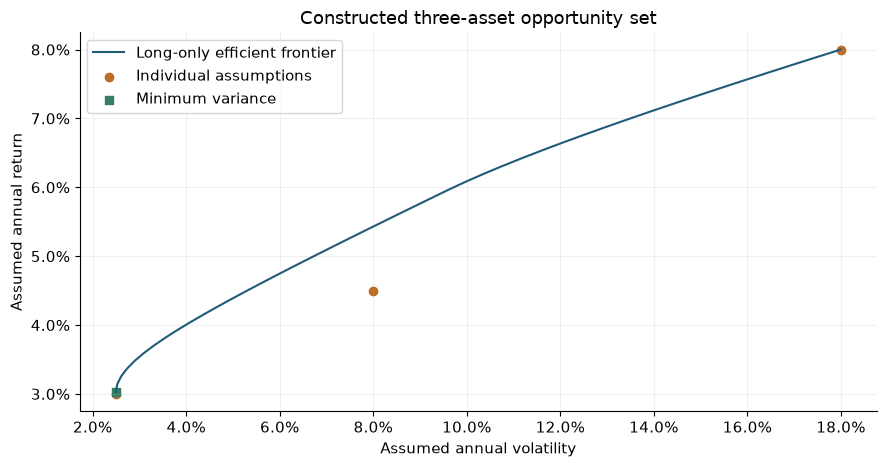

,Return,Volatility,Growth asset,Intermediate bonds,Short bonds
0,3.03%,2.50%,0.54%,0.00%,99.46%
15,4.72%,5.93%,24.39%,33.52%,42.08%
30,6.42%,11.16%,54.79%,45.21%,0.00%
44,8.00%,18.00%,100.00%,0.00%,0.00%


In [3]:
rows = []
for target in np.linspace(gmv @ mu, mu.max(), 45):
    weights = solve(lambda w: w @ cov @ w,
                    [{'type': 'eq', 'fun': lambda w, target=target: w @ mu-target}])
    assert abs(weights @ mu-target) < 1e-8
    rows.append({'Return': weights @ mu, 'Volatility': np.sqrt(weights @ cov @ weights),
                 **dict(zip(names, weights))})
frontier = pd.DataFrame(rows)
fig, ax = plt.subplots()
ax.plot(frontier.Volatility, frontier.Return, color='#205b78', label='Long-only efficient frontier')
ax.scatter(vol, mu, color='#bc6c25', label='Individual assumptions')
ax.scatter(np.sqrt(gmv @ cov @ gmv), gmv @ mu, marker='s', color='#367d63', label='Minimum variance')
ax.set(xlabel='Assumed annual volatility', ylabel='Assumed annual return', title='Constructed three-asset opportunity set')
ax.xaxis.set_major_formatter(PercentFormatter(1)); ax.yaxis.set_major_formatter(PercentFormatter(1))
ax.legend(); fig.tight_layout(); plt.show()
display(frontier.iloc[[0, 15, 30, -1]].style.format('{:.2%}'))

## Change one return estimate

Hold the risk penalty, covariance and trading constraints fixed. This is an input-sensitivity experiment, not evidence that a one-percentage-point forecast error is typical.

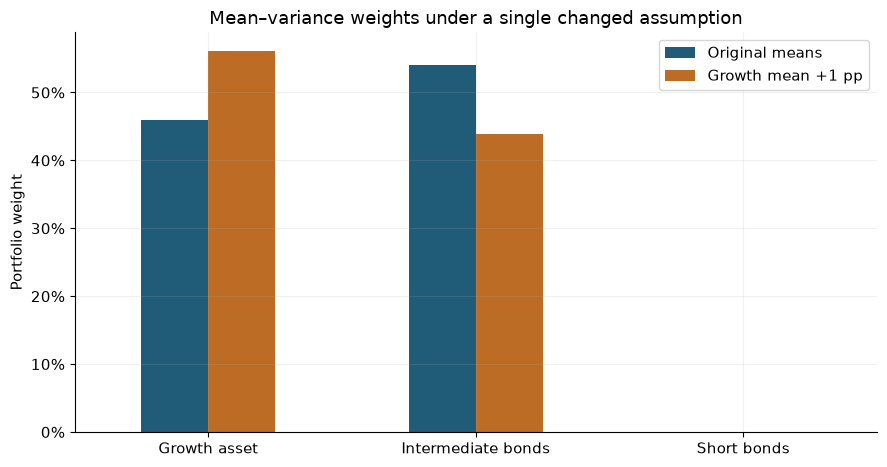

,Original means,Growth mean +1 pp
Growth asset,45.96%,56.05%
Intermediate bonds,54.04%,43.95%
Short bonds,0.00%,0.00%


In [4]:
risk_penalty = 3.0
changed_mu = mu.copy(); changed_mu[0] += 0.01
weights_base = solve(lambda w: 0.5*risk_penalty*(w @ cov @ w)-w @ mu)
weights_changed = solve(lambda w: 0.5*risk_penalty*(w @ cov @ w)-w @ changed_mu)
comparison = pd.DataFrame({'Original means': weights_base, 'Growth mean +1 pp': weights_changed}, index=names)
ax = comparison.plot.bar(rot=0, color=['#205b78', '#bc6c25'])
ax.set(ylabel='Portfolio weight', title='Mean–variance weights under a single changed assumption')
ax.yaxis.set_major_formatter(PercentFormatter(1)); plt.tight_layout(); plt.show()
display(comparison.style.format('{:.2%}'))

## Independent limiting case and interpretation

With independent assets and no return target, minimum-variance weights are proportional to inverse variance. The numerical solution must recover that result. The frontier above still says nothing about the accuracy of the assumed mean returns.

In [5]:
diagonal = np.diag(vol**2)
known = 1/vol**2; known /= known.sum()
numerical = solve(lambda w: w @ diagonal @ w)
np.testing.assert_allclose(numerical, known, atol=2e-5)
print('Budget, return constraints, positive covariance and inverse-variance limiting case: passed.')

Budget, return constraints, positive covariance and inverse-variance limiting case: passed.


[Research note and sources](README.md) · [Historical allocation study](../../study.ipynb)